# Stage 5 — Feature Engineering
**Input:** `data/03_interim/accidents_cleaned.csv`  
**Output:** `data/04_processed/accidents_features.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

INTERIM_DIR   = Path('../../data/03_interim')
PROCESSED_DIR = Path('../../data/04_processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INTERIM_DIR / 'accidents_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1207, 15)


,Accident_ID,Accident_Date,Year,Month,Province,District,Road_Type,Intersection_Type,Time_of_Day,Accident_Severity,Weather_Condition,Road_Surface,Vehicle_Type,Speed_Zone,Driver_Gender
0,1179,2026-01-09,2026,January,Sudurpashchim,Kailali,Highway,Junction,Afternoon,Damage Only,Clear,Slippery,Scooter,50,Male
1,866,2025-03-07,2025,March,Bagmati,Chitwan,Feeder,Curve,Evening,Serious Injury,Clear,Dry,Car,50,Female
2,102,2023-03-23,2023,March,Lumbini,Kapilvastu,Urban,Straight,Morning,Damage Only,Clear,Dry,Truck,30,Male
3,440,2024-02-16,2024,February,Madhesh,Rautahat,Urban,Curve,Afternoon,Minor Injury,Clear,Slippery,Motorbike,80,Male
4,59,2023-02-10,2023,February,Sudurpashchim,Achham,Urban,Straight,Night,Serious Injury,Clear,Wet,Scooter,50,Male


## 5.1 Drop Non-Predictive Columns

In [2]:
df = df.drop(columns=['Accident_ID', 'Accident_Date', 'Month'], errors='ignore')
print('After drop:', df.shape)

After drop: (1207, 12)


## 5.2 Encode Target Label

In [3]:
severity_map = {'Damage Only': 0, 'Minor Injury': 1, 'Serious Injury': 2, 'Fatal': 3}
df['Severity_Label'] = df['Accident_Severity'].map(severity_map)
print(df[['Accident_Severity','Severity_Label']].value_counts().sort_index())

Accident_Severity  Severity_Label
Damage Only        0                 258
Fatal              3                 104
Minor Injury       1                 554
Serious Injury     2                 291
Name: count, dtype: int64


## 5.3 Label Encode Categorical Columns

In [4]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Province', 'District', 'Road_Type', 'Intersection_Type',
            'Time_of_Day', 'Weather_Condition', 'Road_Surface',
            'Vehicle_Type', 'Driver_Gender']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    print(f'{col}: {df[col].nunique()} unique → encoded')

Province: 7 unique → encoded
District: 28 unique → encoded
Road_Type: 4 unique → encoded
Intersection_Type: 4 unique → encoded
Time_of_Day: 4 unique → encoded
Weather_Condition: 4 unique → encoded
Road_Surface: 4 unique → encoded
Vehicle_Type: 7 unique → encoded
Driver_Gender: 3 unique → encoded


## 5.4 Feature Correlation with Target

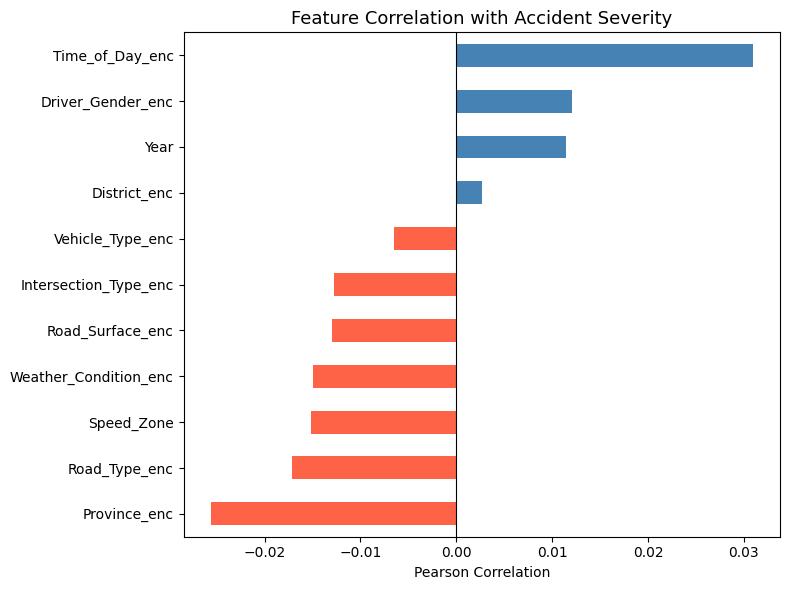

In [5]:
feature_cols = [c for c in df.columns if c.endswith('_enc')] + ['Speed_Zone', 'Year']
corr = df[feature_cols + ['Severity_Label']].corr()['Severity_Label'].drop('Severity_Label').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Accident Severity', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 5.5 Build Final Feature Matrix

In [6]:
X = df[feature_cols]
y = df['Severity_Label']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Class distribution:\n', y.value_counts().sort_index())

Feature matrix shape: (1207, 11)
Target shape: (1207,)
Class distribution:
 Severity_Label
0    258
1    554
2    291
3    104
Name: count, dtype: int64


## 5.6 Save Processed Dataset

In [7]:
df_out = X.copy()
df_out['Severity_Label'] = y
df_out.to_csv(PROCESSED_DIR / 'accidents_features.csv', index=False)
print('Saved to:', PROCESSED_DIR / 'accidents_features.csv')
print('Shape:', df_out.shape)

Saved to: ../../data/04_processed/accidents_features.csv
Shape: (1207, 12)
